<h1>Veritas</h1>
<h4>Works like ChipChat, AutoChip, Verigen and others have shown that LLMs can be used for verilog code generation. But it is often seen that the code generated by the LLM end up having issues like syntax errors and incorrect logic. To analyse the correctness of the code an expert's supervision is often required. Exhaustive test-cases are written to verify and test the logic. In veritas we integrate the verification and testing phase with the generation phase itself. We leverage the power of LLMs to understand initial simple contexts and generate complex outputs based on that. Each circuit is a combination of some logics like AND, NAND, NOR, XNOR etc. Each of these logics have an equivalent Conjunctive Normal Form (CNF) representation (refer figure below). A full circuit can be represented as the conjunction of CNF clauses representing the individual logic gates in the circuit. Our Veritas framework starts with CNF generation for simple circuits and used the generated result as future context to generate bigger and more complex circuits.</h4>



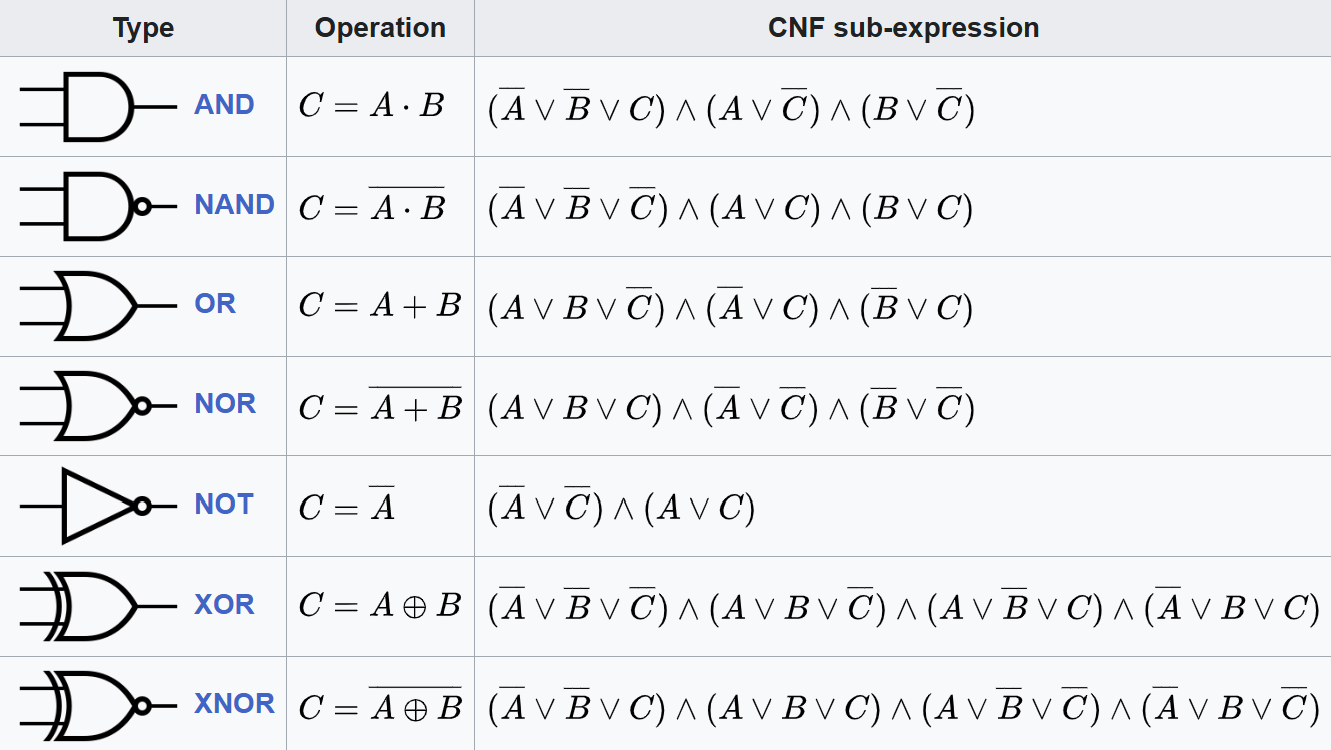

<h4>Veritas generates correct CNF equations for various designs like adder, subtractor, multiplexer, multiplicator, decoder.
Veritas leverages the idea that correct CNF can always be converted to correct verilog code that does not require further testing.</h4>
    Design Name :  Possible configuration

    "adder":       ["1-bit", "2-bit", "3-bit", "4-bit", "5-bit"]
    "subtractor":  ["1-bit", "2-bit", "3-bit", "4-bit", "5-bit"]
    "multiplier":  ["1-bit", "2-bit", "3-bit"]
    "decoder":     ["1x2", "2x4", "3x8", "4x16", "5x32"]
    "multiplexer": ["2x1", "4x1", "8x1", "16x1", "32x1"]


In [ ]:
!pip install -q -U google-generativeai

In [ ]:
DESIGN = "adder"
TYP = "3-bit"

<h4>This part of the code enquires gpt-5-mini model incrementally to get the correct CNF equation for a design. This might take a couple of minutes due to multiple communication with the LLM. the idea is to first obtain the cnf for the smallest version of the design. Then asking the LLM to use it as reference to come up with bigger and more complex designs.</h4>

In [ ]:
import google.generativeai as genai
genai.configure(api_key="")

print("modellist：")
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


modellist：
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025


In [ ]:
import google.generativeai as genai
import time

genai.configure(api_key="")
model = genai.GenerativeModel('gemini-2.5-flash')

start = time.time()
try:
    response = model.generate_content("Hi, test.")
    print(f"responed text: {response.text}")
    print(f" time consume: {time.time() - start:.2f} 秒")
except Exception as e:
    print(f" error: {e}")

responed text: Hello! How can I help you today?
 time consume: 2.77 秒


In [ ]:
import google.generativeai as genai
import re
import time

#  API
genai.configure(api_key="")
model = genai.GenerativeModel('gemini-2.5-flash')

DESIGN = "adder"
TYP = "3-bit" # This TYP will be the final target bit-width

# Global inputs/outputs for the final design
final_inputs = "A0,B0,A1,B1,A2,B2,Cin"
final_outputs = "S0,S1,S2,Cout"

def _get_cnf_for_bitwidth(design, bit_str, inputs_str, outputs_str, context_cnfs=""):
    """Helper to get CNF for a specific bit-width with optional context."""
    prompt = f"""
    Generate CNF formulas for a {bit_str} {design}.
    Assume inputs are {inputs_str} and outputs are {outputs_str}.
    {context_cnfs}
    Instructions:
    - For each output, provide a CNF equation in the format: OUTPUT_NAME = (literal1 | literal2) & (literal3 | literal4) ...
    - Use actual input and output variable names (e.g., A0, B0, S0, Cout).
    - Each clause should be enclosed in parentheses, and literals within a clause should be separated by '|'.
    - Clauses should be separated by '&'.
    - Negation should be represented by '!' (e.g., !A0).
    - STRICTLY NO explanation, NO markdown code blocks, NO backticks.
    - Just the raw CNF equations.
    """
    print(f" Requesting Gemini to generate CNF for {design} {bit_str}...")

    # Implement retry with exponential backoff for API calls
    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = model.generate_content(prompt)
            content = response.text
            clean_cnf = re.sub(r'```[a-zA-Z]*', '', content)
            clean_cnf = clean_cnf.replace('```', '').strip()
            return clean_cnf
        except Exception as e:
            if "TooManyRequests" in str(e) and attempt < max_retries - 1:
                print(f"   TooManyRequests error, retrying in {2**(attempt+1)} seconds...")
                time.sleep(2**(attempt+1))
            else:
                raise
    return ""

def generate_cnf_incrementally(design, target_typ):
    print(f" Initiating incremental CNF generation for {design} {target_typ}...")

    # Determine target bit-width
    match = re.match(r"(\d+)-bit", target_typ)
    if not match:
        raise ValueError(f"Invalid target type format: {target_typ}. Expected 'X-bit'.")
    target_bit_width = int(match.group(1))

    # Step 1: Generate 1-bit adder CNF
    bit_str_1 = "1-bit"
    inputs_1 = "A0,B0,Cin"
    outputs_1 = "S0,Cout"
    cnf_1_bit = _get_cnf_for_bitwidth(design, bit_str_1, inputs_1, outputs_1)
    print(f" Generated 1-bit CNF. First 3 lines:\n{chr(10).join(cnf_1_bit.split(chr(10))[:3])}")
    time.sleep(1) # Small delay to avoid hitting rate limits too quickly

    # Step 2: Generate 2-bit adder CNF using 1-bit as context, if target > 1
    cnf_2_bit = ""
    if target_bit_width >= 2:
        bit_str_2 = "2-bit"
        inputs_2 = "A0,B0,A1,B1,Cin"
        outputs_2 = "S0,S1,Cout"
        context_2 = f"Use the following 1-bit {design} CNF as reference:\n{cnf_1_bit}\n"
        cnf_2_bit = _get_cnf_for_bitwidth(design, bit_str_2, inputs_2, outputs_2, context_2)
        print(f" Generated 2-bit CNF. First 3 lines:\n{chr(10).join(cnf_2_bit.split(chr(10))[:3])}")
        time.sleep(1)

    # Step 3: Generate target bit-width adder CNF using smaller components as context
    # For a 3-bit adder, we use 1-bit and 2-bit as context.
    final_cnf = ""
    if target_bit_width == 3: # Assuming 3-bit is the specific target from TYP
        context_final = ""
        if cnf_1_bit:
            context_final += f"Use the following 1-bit {design} CNF as reference:\n{cnf_1_bit}\n"
        if cnf_2_bit:
            context_final += f"Use the following 2-bit {design} CNF as reference:\n{cnf_2_bit}\n"

        final_cnf = _get_cnf_for_bitwidth(design, target_typ, final_inputs, final_outputs, context_final)
        print(f" Generated final {target_typ} CNF. First 3 lines:\n{chr(10).join(final_cnf.split(chr(10))[:3])}")

    else:
        # Fallback or handle other specific bit-widths directly if not part of this incremental flow
        final_cnf = _get_cnf_for_bitwidth(design, target_typ, final_inputs, final_outputs, "")
        print(f" Generated final {target_typ} CNF (direct). First 3 lines:\n{chr(10).join(final_cnf.split(chr(10))[:3])}")


    # Save the final CNF to file
    filename = f"{design}_{target_typ}.cnf"
    with open(filename, "w") as f:
        f.write(final_cnf)

    print(f" Succeed generate！Final CNF for {design} {target_typ} saved as: {filename}")
    return final_cnf

# Run the incremental generation
cnf = generate_cnf_incrementally(DESIGN, TYP)
inputs = final_inputs
outputs = final_outputs

 Initiating incremental CNF generation for adder 3-bit...
 Requesting Gemini to generate CNF for adder 1-bit...
 Generated 1-bit CNF. First 3 lines:
S0 = (A0 | B0 | Cin) & (A0 | !B0 | !Cin) & (!A0 | B0 | !Cin) & (!A0 | !B0 | Cin)
Cout = (A0 | B0 | Cin) & (A0 | B0 | !Cin) & (A0 | !B0 | Cin) & (!A0 | B0 | Cin)
 Requesting Gemini to generate CNF for adder 2-bit...
 Generated 2-bit CNF. First 3 lines:
S0 = (A0 | B0 | Cin) & (A0 | !B0 | !Cin) & (!A0 | B0 | !Cin) & (!A0 | !B0 | Cin)
S1 = (A1 | B1 | A0 | B0 | Cin) & (A1 | B1 | A0 | B0 | !Cin) & (A1 | B1 | A0 | !B0 | Cin) & (A1 | B1 | !A0 | B0 | Cin) & (A1 | !B1 | !A0 | !B0) & (A1 | !B1 | !A0 | !Cin) & (A1 | !B1 | !B0 | !Cin) & (!A1 | B1 | !A0 | !B0) & (!A1 | B1 | !A0 | !Cin) & (!A1 | B1 | !B0 | !Cin) & (!A1 | !B1 | A0 | B0 | Cin) & (!A1 | !B1 | A0 | B0 | !Cin) & (!A1 | !B1 | A0 | !B0 | Cin) & (!A1 | !B1 | !A0 | B0 | Cin)
Cout = (A1 | B1 | A0 | B0 | Cin) & (A1 | B1 | A0 | B0 | !Cin) & (A1 | B1 | A0 | !B0 | Cin) & (A1 | B1 | !A0 | B0 | Cin) & (

<h4>The following converts the cnf obtained from the LLM to a bench format. Make sure the inputs and the output names are properly declared.</h4>

In [ ]:
#!/usr/bin/env python3
import argparse
import itertools
import re
import sys
from typing import Dict, List, Tuple, Set

Literal = Tuple[str, bool]   # (var, is_neg)
Clause  = List[Literal]      # OR of literals
CNF     = List[Clause]       # AND of clauses

# Define DESIGN and TYP locally for this cell
DESIGN = "adder"
TYP = "3-bit"
inputs = "A0,B0,A1,B1,A2,B2,Cin"
outputs = "S0,S1,S2,Cout"


# ---------- CLI helpers ----------
def parse_name_list(s: str) -> List[str]:
    # accept comma or whitespace separated
    toks = [t for t in re.split(r"[,\s]+", s.strip()) if t]
    if not toks:
        raise ValueError("Empty variable list.")
    # sanity: identifiers only
    bad = [t for t in toks if not re.match(r"^[A-Za-z_]\w*$", t)]
    if bad:
        raise ValueError(f"Bad names in list: {', '.join(bad)}")
    return toks


# ---------- Normalization & parsing ----------
def normalize_ops(s: str) -> str:
    """Normalize logical symbols but PRESERVE line breaks."""
    s = (s.replace("∧", "&")
           .replace("∨", "|")
           .replace("¬", "!")
           .replace("’", "'")
           .replace("～", "!")
           .replace("AND", "&")
           .replace("OR",  "|"))
    s = s.replace("\u00A0", " ")
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"[ \t]+\n", "\n", s)
    return s


def extract_equations_from_text(text: str) -> Dict[str, str]:
    """
    Find all segments of the form:
        NAME = <CNF...>
    capturing the RHS up to the next NAME '=' line (or EOF).
    """
    t = normalize_ops(text)
    pattern = re.compile(r"(?ms)^\s*([A-Za-z_]\w*)\s*=\s*(.+?)(?=^\s*[A-Za-z_]\w*\s*=|\Z)")
    eqs: Dict[str, str] = {}
    for m in pattern.finditer(t):
        lhs = m.group(1)
        rhs = m.group(2).strip().rstrip(" .;'") # Remove trailing ' as well
        eqs[lhs] = rhs
    if not eqs:
        raise ValueError("No equations of the form NAME = ... were found in the CNF text.")
    return eqs


def parse_cnf(rhs: str) -> CNF:
    """
    Parse CNF: (clause) & (clause) & ...
    Each (clause) is 'lit | lit | ...' where '!' negates a variable name.
    """
    s = normalize_ops(rhs).strip()
    clauses: CNF = []
    i, n = 0, len(s)

    def skip_ws(k: int) -> int:
        while k < n and s[k].isspace():
            k += 1
        return k

    i = skip_ws(i)
    parsed_any = False
    while i < n:
        i = skip_ws(i)
        if i >= n:
            break
        if s[i] != '(': # Ensure s[i] is '(' here
            # If we've already parsed some clauses, and we see something that's not '(', break.
            # This means a single clause without parentheses must be the *only* clause.
            if parsed_any: # If we've parsed something already, and this isn't a new '(', then we're done.
                break
            # allow single clause without parentheses
            if '(' not in s: # If no parentheses in the whole string, treat the whole string as a single clause.
                inner = s
                group_end = n
            else: # If there are parentheses, but this isn't one, then it's a parsing error for the start.
                raise ValueError(f"Expected '(' or end of input, found '{s[i]}' at index {i}")
        else:
            # If s[i] is '(', proceed as usual for grouped clauses
            depth = 0
            start = i
            while i < n:
                ch = s[i]
                if ch == '(': # Increment depth for '(' to handle nested parentheses correctly
                    depth += 1
                elif ch == ')': # Decrement depth for ')'
                    depth -= 1
                    if depth == 0: # When depth returns to 0, we've found the end of the current top-level group.
                        i += 1
                        break
                i += 1
            if depth != 0: # If depth isn't 0 after the loop, it means unmatched parentheses.
                raise ValueError("Unbalanced parentheses in CNF.")
            group = s[start:i]
            inner = group[1:-1].strip() # Extract content inside the top-level parentheses

        lits_raw = [tok.strip() for tok in inner.split('|')] # Split by '|' to get individual literals
        clause: Clause = []
        for lit in lits_raw:
            if not lit:
                continue # Skip empty literals resulting from split
            neg = False
            while lit.startswith('!'): # Handle negation by '!' (can be multiple '!')
                neg = not neg
                lit = lit[1:].strip()
            if not re.match(r'^[A-Za-z_]\w*$', lit):
                raise ValueError(f"Bad literal token: '{lit}' in clause '{inner}'")
            clause.append((lit, neg))
        if not clause:
            raise ValueError("Empty clause encountered.") # Ensure clauses are not empty
        clauses.append(clause)
        parsed_any = True

        i = skip_ws(i) # Skip whitespace before checking for '&'
        if i < n and s[i] == '&': # If '&' is present, continue parsing next clause.
            i += 1
        elif i < n: # If there are more characters but not '&', it means extra unparsed text.
            raise ValueError(f"Unexpected token '{s[i]}' after clause. Expected '&' or end of input.")
        else:
            break # End of string

    if not clauses:
        raise ValueError("No clauses parsed from RHS.")
    return clauses


def vars_in_cnf(cnf: CNF) -> Set[str]:
    return {v for clause in cnf for (v, _) in clause}


# ---------- CNF evaluation ----------
def eval_clause(clause: Clause, asg: Dict[str, int]) -> bool:
    for v, is_neg in clause:
        if v not in asg:
            raise KeyError(f"Variable '{v}' missing in assignment")
        val = asg[v]
        if is_neg:
            val = 1 - val
        if val == 1:
            return True
    return False


def eval_cnf(cnf: CNF, asg: Dict[str, int]) -> bool:
    return all(eval_clause(c, asg) for c in cnf)


# ---------- Derivation with dependencies ----------
def topo_order_equations(cnfs: Dict[str, CNF], input_vars: List[str]) -> List[str]:
    """
    Topological order of LHS variables based on RHS references to other LHS vars.
    Self-reference is ignored.
    """
    inputs = set(input_vars)
    lhs_vars = set(cnfs.keys())
    deps: Dict[str, Set[str]] = {v: set() for v in lhs_vars}

    for v, cnf in cnfs.items():
        for sym in vars_in_cnf(cnf):
            if sym == v:
                continue
            if sym in lhs_vars:
                deps[v].add(sym)
            elif sym not in inputs:
                raise ValueError(
                    f"Symbol '{sym}' used in equation for '{v}' is not an input and has no defining equation."
                )

    indeg = {v: 0 for v in lhs_vars}
    for v in lhs_vars:
        for d in deps[v]:
            indeg[v] += 1
    queue = [v for v in lhs_vars if indeg[v] == 0]
    order: List[str] = []
    while queue:
        u = queue.pop()
        order.append(u)
        for w in lhs_vars:
            if u in deps[w]:
                indeg[w] -= 1
                if indeg[w] == 0:
                    queue.append(w)

    if len(order) != len(lhs_vars):
        raise ValueError("Cyclic dependency among equations (excluding self-references).")
    return order


def derive_on_set_for_var(
    var: str,
    cnf: CNF,
    input_vars: List[str],
    value_oracle: Dict[str, Dict[Tuple[int, ...], int]]
) -> List[Tuple[int, ...]]:
    """
    Compute ON-set for 'var' as a function of base inputs.
    value_oracle maps any dependent LHS symbols to their truth tables over inputs.
    """
    on_set: List[Tuple[int, ...]] = []
    cnf_syms = vars_in_cnf(cnf)
    deps = [s for s in cnf_syms if s != var and s in value_oracle]

    for bits in itertools.product([0, 1], repeat=len(input_vars)):
        asg = {v: b for v, b in zip(input_vars, bits)}
        for d in deps:
            asg[d] = value_oracle[d][bits]

        if var in cnf_syms:
            asg0 = dict(asg); asg0[var] = 0
            asg1 = dict(asg); asg1[var] = 1
            sat0 = eval_cnf(cnf, asg0)
            sat1 = eval_cnf(cnf, asg1)
            if sat0 and not sat1:
                pass
            elif sat1 and not sat0:
                on_set.append(bits)
            elif sat0 and sat1:
                raise ValueError(f"Ambiguous CNF for '{var}' at inputs {asg}: both 0 and 1 satisfy.")
            else:
                raise ValueError(f"Inconsistent CNF for '{var}' at inputs {asg}: neither value satisfies.")
        else:
            # If var is not in cnf_syms, it means the equation is just a function of other variables.
            # We evaluate the CNF as a whole; if it's true, then 'var' is 1 (or it is implied).
            val = 1 if eval_cnf(cnf, asg) else 0
            if val == 1:
                on_set.append(bits)

    return on_set


# ---------- Emit .bench (SOP) ----------
def emit_bench(
    input_vars: List[str],
    output_vars: List[str],
    on_sets: Dict[str, List[Tuple[int, ...]]]
) -> str:
    lines: List[str] = []
    for v in input_vars:
        lines.append(f"INPUT({v})")
    for v in output_vars:
        lines.append(f"OUTPUT({v})")
    lines.append("")

    # NOT wires for all inputs
    notw = {v: f"n_not_{v}" for v in input_vars}
    for v in input_vars:
        lines.append(f"{notw[v]} = NOT({v})")
    lines.append("")

    # Constants via first input
    base = input_vars[0]
    lines.append(f"CONST0 = AND({base}, {notw[base]}) ")
    lines.append(f"CONST1 = OR({base}, {notw[base]}) ")
    lines.append("")

    for out in output_vars:
        on_mins = on_sets[out]
        if len(on_mins) == 0:
            lines.append(f"{out} = BUF(CONST0)")
            lines.append("")
            continue
        if len(on_mins) == (1 << len(input_vars)):
            lines.append(f"{out} = BUF(CONST1)")
            lines.append("")
            continue

        prod_terms = []
        for i, bits in enumerate(on_mins):
            terms = [ (v if b else notw[v]) for v, b in zip(input_vars, bits) ]
            if len(terms) == 1:
                prod_terms.append(terms[0])
            else:
                pname = f"p_{out}_{i}"
                lines.append(f"{pname} = AND({', '.join(terms)}) ")
                prod_terms.append(pname)

        if len(prod_terms) == 1:
            lines.append(f"{out} = BUF({prod_terms[0]}) ")
        else:
            lines.append(f"{out} = OR({', '.join(prod_terms)}) ")
        lines.append("")

    return "\n".join(lines).strip() + "\n"


# ---------- Main ----------
def cnf_to_bench(inputs,outputs,cnf) :

    input_vars  = parse_name_list(inputs)
    output_vars = parse_name_list(outputs)

    # 1) Extract equations
    raw_eqs = extract_equations_from_text(cnf)   # {lhs: rhs_str}
    print("Found equations:", ", ".join(raw_eqs.keys()), file=sys.stderr)

    # 2) Parse to CNF
    cnfs: Dict[str, CNF] = {lhs: parse_cnf(rhs) for lhs, rhs in raw_eqs.items()}

    # 3) Topo order of deps between LHS vars
    order = topo_order_equations(cnfs, input_vars)

    # 4) Derive ON-sets for all LHS vars in order
    oracle: Dict[str, Dict[Tuple[int, ...], int]] = {}
    all_on_sets: Dict[str, List[Tuple[int, ...]]] = {}
    all_patterns = list(itertools.product([0, 1], repeat=len(input_vars)))  # used to make oracles total
    for lhs in order:
        on_set = derive_on_set_for_var(lhs, cnfs[lhs], input_vars, oracle)
        all_on_sets[lhs] = on_set
        # Build total truth table for dependents
        table = {bits: 0 for bits in all_patterns}
        table.update({bits: 1 for bits in on_set})
        oracle[lhs] = table

    # 5) Ensure all requested outputs are defined
    missing = [o for o in output_vars if o not in all_on_sets]
    if missing:
        raise ValueError(f"Missing CNF equations for outputs: {missing}")

    # 6) Emit bench
    bench = emit_bench(input_vars, output_vars, all_on_sets)

    f = open(DESIGN+"_"+TYP+".bench","w")
    f.write(bench)
    f.close()

cnf_to_bench(inputs,outputs,cnf)


Found equations: S0, S1, S2, Cout


<h4>The bench file can be simulated using the following code. You also get a .csv containing different input vectors and the corresponding outputs</h4>

In [ ]:
import argparse
import csv
import re
from collections import defaultdict, deque
from typing import Dict, List

# -------------------- Core circuit model --------------------
class BenchCircuit:
    def __init__(self, inputs: List[str], outputs: List[str], gates: Dict[str, tuple]):
        self.inputs = inputs
        self.outputs = outputs
        self.gates = gates  # name -> (OP, [fanins])
        self.order = self._topo_order()

    @staticmethod
    def from_file(path: str) -> "BenchCircuit":
        with open(path, "r") as f:
            text = f.read()
        return BenchCircuit.parse(text)

    @staticmethod
    def parse(text: str) -> "BenchCircuit":
        inputs, outputs, gates = [], [], {}
        for raw in text.splitlines():
            line = raw.strip()
            if not line or line.startswith("#"):
                continue

            # INPUT(name)
            if line.upper().startswith("INPUT("):
                m = re.match(r"INPUT\(\s*([A-Za-z_]\w*)\s*\)\s*$", line, flags=re.I)
                if not m:
                    raise ValueError(f"Bad INPUT line: {line}")
                inputs.append(m.group(1))
                continue

            # OUTPUT(name)
            if line.upper().startswith("OUTPUT("):
                m = re.match(r"OUTPUT\(\s*([A-Za-z_]\w*)\s*\)\s*$", line, flags=re.I)
                if not m:
                    raise ValueError(f"Bad OUTPUT line: {line}")
                outputs.append(m.group(1))
                continue

            # name = OP(arg1, arg2, ...)
            m = re.match(
                r"([A-Za-z_]\w*)\s*=\s*([A-Za-z_]\w*)\s*\(\s*(.*?)\s*\)\s*$",
                line,
            )
            if not m:
                raise ValueError(f"Bad gate line: {line}")
            name, op, args = m.groups()
            args_list = [a.strip() for a in args.split(",")] if args else []
            gates[name] = (op.upper(), args_list)

        return BenchCircuit(inputs, outputs, gates)

    def _topo_order(self) -> List[str]:
        indeg = defaultdict(int)
        adj = defaultdict(list)
        nodes = set(self.inputs) | set(self.gates.keys())

        for dst, (_, srcs) in self.gates.items():
            for s in srcs:
                adj[s].append(dst)
                indeg[dst] += 1
                nodes.add(s)

        q = deque([n for n in nodes if indeg[n] == 0])
        order = []
        while q:
            u = q.popleft()
            order.append(u)
            for v in adj[u]:
                indeg[v] -= 1
                if indeg[v] == 0:
                    q.append(v)

        missing = [n for n in self.gates.keys() if n not in order]
        if missing:
            raise ValueError(f"Cycle detected or undefined refs: {missing}")
        return order

    @staticmethod
    def _gate_eval(op: str, vals: List[int]) -> int:
        op = op.upper()
        if op == "NOT":
            if len(vals) != 1:
                raise ValueError("NOT expects 1 input")
            return 1 - vals[0]
        if op == "BUF":
            if len(vals) != 1:
                raise ValueError("BUF expects 1 input")
            return vals[0]
        if op == "AND":
            r = 1
            for v in vals:
                r &= v
            return r
        if op == "OR":
            r = 0
            for v in vals:
                r |= v
            return r
        if op == "NAND":
            return 1 - BenchCircuit._gate_eval("AND", vals)
        if op == "NOR":
            return 1 - BenchCircuit._gate_eval("OR", vals)
        if op == "XOR":
            r = 0
            for v in vals:
                r ^= v
            return r
        if op == "XNOR":
            return 1 - BenchCircuit._gate_eval("XOR", vals)
        raise ValueError(f"Unknown gate type: {op}")

    def simulate_once(self, assignment: Dict[str, int]) -> Dict[str, int]:
        """assignment provides values for all INPUT() signals (0/1)."""
        values: Dict[str, int] = {}
        for v in self.inputs:
            if v not in assignment:
                raise KeyError(f"Missing input '{v}' in assignment")
            values[v] = int(assignment[v]) & 1

        for node in self.order:
            if node in self.inputs:
                continue
            if node not in self.gates:
                continue
            op, srcs = self.gates[node]
            vals = [values[s] for s in srcs]
            values[node] = self._gate_eval(op, vals)

        return {o: values[o] for o in self.outputs}

# -------------------- CLI helpers --------------------
def parse_assigns(pairs: List[str]) -> Dict[str, int]:
    out = {}
    for p in pairs:
        if "=" not in p:
            raise ValueError(f"Bad --assign '{p}', use NAME=0/1")
        k, v = p.split("=", 1)
        k = k.strip()
        v = v.strip()
        if v not in ("0", "1"):
            raise ValueError(f"Assignment for {k} must be 0 or 1, got '{v}'")
        out[k] = int(v)
    return out

def truth_table(circ: BenchCircuit, input_order: List[str]):
    if not input_order:
        input_order = circ.inputs[:] # Use circuit inputs if no order specified
    # ensure order correctness
    for v in input_order:
        if v not in circ.inputs:
            raise ValueError(f"'{v}' is not an INPUT() of this circuit")

    header = input_order + circ.outputs
    rows = []
    # Iterate in binary counting order
    n = len(input_order)
    for i in range(1 << n):
        vec = {input_order[j]: ((i >> (n - 1 - j)) & 1) for j in range(n)}
        outs = circ.simulate_once(vec)
        rows.append([*(vec[v] for v in input_order), *(outs[o] for o in circ.outputs)])
    return header, rows

def bench_simulator(design, typ, inputs_str_param, outputs_str_param):

    circ = BenchCircuit.from_file(design+"_"+typ+".bench")
    csv_mode = False
    csv_file = design+"_"+typ+".csv"
    table = True
    save_table = True
    csv_table_file = design+"_"+typ+"_tab.csv"

    # Mode 1: CSV batch
    if csv_mode:
        with open(csv_file, newline="") as f:
            reader = csv.DictReader(f)
            field_set = set(reader.fieldnames or [])
            miss = [v for v in circ.inputs if v not in field_set]
            if miss:
                raise SystemExit(f"CSV missing input columns: {miss}")
            writer = csv.DictWriter(
                f=__import__("sys").stdout,
                fieldnames=(reader.fieldnames + circ.outputs),
            )
            writer.writeheader()
            for row in reader:
                asg = {v: int(row[v]) for v in circ.inputs}
                outs = circ.simulate_once(asg)
                row.update({k: outs[k] for k in circ.outputs})
                writer.writerow(row)
        return

    # Mode 2: Truth table
    if table:
        order = [x.strip() for x in inputs_str_param.split(",")] if inputs_str_param else []
        header, rows = truth_table(circ, order)
        if save_table:
            with open(csv_table_file, "w", newline="") as f:
                w = csv.writer(f)
                w.writerow(header)
                w.writerows(rows)
        # Print to stdout
        print(" ".join(f"{h:>5}" for h in header))
        for r in rows:
            print(" ".join(f"{x:>5}" for x in r))
        return

    # # Mode 3: Single assignment
    # assigns = parse_assigns(args.assign)
    # missing = [v for v in circ.inputs if v not in assigns]
    # if missing:
    #     raise SystemExit(
    #         f"Missing input assignments for: {missing}\n"
    #         f"Provide all with --assign NAME=0/1 (repeat per input)."
    #     )
    #outs = circ.simulate_once(assigns)
    #print("Inputs:", ", ".join(f"{k}={assigns[k]}" for k in circ.inputs))
    #print("Outputs:", ", ".join(f"{k}={outs[k]}" for k in circ.outputs))

bench_simulator(DESIGN,TYP, inputs, outputs)

   A0    B0    A1    B1    A2    B2   Cin    S0    S1    S2  Cout
    0     0     0     0     0     0     0     0     0     0     0
    0     0     0     0     0     0     1     1     0     0     0
    0     0     0     0     0     1     0     1     0     0     1
    0     0     0     0     0     1     1     0     1     0     1
    0     0     0     0     1     0     0     1     1     1     0
    0     0     0     0     1     0     1     0     0     0     0
    0     0     0     0     1     1     0     0     1     0     1
    0     0     0     0     1     1     1     1     0     1     1
    0     0     0     1     0     0     0     1     0     0     0
    0     0     0     1     0     0     1     0     1     0     0
    0     0     0     1     0     1     0     0     0     0     1
    0     0     0     1     0     1     1     1     1     0     1
    0     0     0     1     1     0     0     0     1     0     0
    0     0     0     1     1     0     1     1     0     1     0
    0     

<h4>This code generates the verilog file from the bench. Since the CNF generated is correct the verilog code generated is also correct and does not require further testing.</h4>

In [ ]:
from __future__ import annotations
import argparse
import os
import re
import sys
from typing import Dict, List, Tuple, Set

Gate = Tuple[str, List[str]]  # (op, args)


def parse_bench(path: str, allow_lut: bool = False) -> Tuple[Set[str], Set[str], Dict[str, Gate]]:
    """
    Parse a .bench file.
    Returns: (inputs, outputs, assigns) where assigns maps net -> (op, args)
    """
    inputs: Set[str] = set()
    outputs: Set[str] = set()
    assigns: Dict[str, Gate] = {}

    # Patterns
    rx_input  = re.compile(r"^\s*INPUT\s*\(\s*([A-Za-z_]\w*)\s*\)\s*$", re.I)
    rx_output = re.compile(r"^\s*OUTPUT\s*\(\s*([A-Za-z_]\w*)\s*\)\s*$", re.I)
    # e.g.  out = OP(a,b,c)
    rx_gate   = re.compile(r"^\s*([A-Za-z_]\w*)\s*=\s*([A-Za-z_]\w*)\s*\(\s*([^\)]*)\s*\)\s*$")
    # e.g.  out = LUT 0x1f (a,b,c)
    rx_lut    = re.compile(r"^\s*([A-Za-z_]\w*)\s*=\s*LUT\s+([^\s\(\)]+)\s*\(\s*([^\)]*)\s*\)\s*$", re.I)

    with open(path, "r", encoding="utf-8") as f:
        for ln, raw in enumerate(f, 1):
            line = raw.split("#", 1)[0].strip()  # strip comments and whitespace
            if not line:
                continue

            m = rx_input.match(line)
            if m:
                name = m.group(1)
                if name in inputs:
                    print(f"[warn] duplicate INPUT '{name}' (line {ln})", file=sys.stderr)
                inputs.add(name)
                continue

            m = rx_output.match(line)
            if m:
                name = m.group(1)
                outputs.add(name)
                continue

            m = rx_lut.match(line)
            if m:
                if not allow_lut:
                    raise ValueError(
                        f"Found LUT on line {ln} but --allow-lut not set.\n"
                        f"Line: {raw.strip()}\n"
                        f"Tip: re-run with --allow-lut or re-synthesize without LUTs."
                    )
                dest, hexcode, argstr = m.groups()
                args = [t.strip() for t in argstr.split(",") if t.strip()]
                assigns[dest] = ("LUT:" + hexcode, args)
                continue

            m = rx_gate.match(line)
            if m:
                dest, op, argstr = m.groups()
                args = [t.strip() for t in argstr.split(",") if t.strip()]
                op_up = op.upper()
                if op_up == "BUFF":
                    op_up = "BUF"
                # sanity checks
                if op_up in ("NOT", "BUF") and len(args) != 1:
                    raise ValueError(f"Gate '{op_up}' on line {ln} must have exactly 1 input: {raw.strip()}")
                if op_up in ("AND","OR","NAND","NOR","XOR","XNOR") and len(args) < 2:
                    raise ValueError(f"Gate '{op_up}' on line {ln} must have ≥2 inputs: {raw.strip()}")
                assigns[dest] = (op_up, args)
                continue

            raise ValueError(f"Unrecognized .bench line {ln}: {raw.strip()}")

    # Sanity: outputs should be declared, even if later driven by assign
    undeclared_assigned = set(assigns.keys()) - inputs - outputs
    # These are internal wires; fine. We'll declare them as wires in Verilog.
    # But warn if an INPUT is also assigned.
    illegal_drives = set(assigns.keys()) & inputs
    if illegal_drives:
        raise ValueError(f"These nets are declared INPUT but also driven by gates: {sorted(illegal_drives)}")

    return inputs, outputs, assigns


def expr_for_gate(op: str, args: List[str]) -> str:
    """Return a Verilog expression string for a given gate op/args (no semicolon)."""
    if op == "BUF":
        return f"{args[0]}"
    if op == "NOT":
        return f"~({args[0]})"
    join = None
    inv  = None
    if op == "AND":
        join, inv = " & ", ""
    elif op == "NAND":
        join, inv = " & ", "~"
    elif op == "OR":
        join, inv = " | ", ""
    elif op == "NOR":
        join, inv = " | ", "~"
    elif op == "XOR":
        join, inv = " ^ ", ""
    elif op == "XNOR":
        join, inv = " ^ ", "~"
    else:
        raise KeyError(op)
    inner = "(" + join.join(args) + ")"
    return (inv + inner) if inv else inner


def sop_expr_from_lut(hexcode: str, inputs: List[str]) -> str:
    """
    Expand a LUT constant into a Verilog SOP expression over 'inputs'.
    hexcode may be '0x..' or decimal. LSB corresponds to inputs pattern 0..0.
    """
    # parse code
    code = int(hexcode, 0)
    n = len(inputs)
    if n == 0:
        return "1'b0" if code == 0 else "1'b1"
    terms: List[str] = []
    for i in range(1 << n):
        bit = (code >> i) & 1
        if bit == 0:
            continue
        # build minterm for pattern i
        lits = []
        for k, name in enumerate(inputs):
            val = (i >> k) & 1  # LSB = inputs[0]
            lits.append(name if val == 1 else f"~{name}")
        if len(lits) == 1:
            terms.append(lits[0])
        else:
            terms.append("(" + " & ".join(lits) + ")")
    if not terms:
        return "1'b0"
    return " | ".join(terms)


def write_verilog(
    out_path: str,
    module_name: str,
    inputs: Set[str],
    outputs: Set[str],
    assigns: Dict[str, Gate],
    allow_lut: bool = False,
) -> None:
    # Determine internal wires: driven nets that are not ports
    driven = set(assigns.keys())
    ports_in  = sorted(inputs)
    ports_out = sorted(outputs)
    internals = sorted(driven - inputs - outputs)
    module_name = module_name.replace("-","_")


    with (open(out_path, "w", encoding="utf-8") if out_path != "-" else sys.stdout) as f:
        w = f.write
        w("// Generated by bench2verilog.py\n")
        w(f"module {module_name}(\n")
        # Port list: inputs then outputs
        port_list = ports_in + ports_out
        w("    " + ", ".join(port_list) + "\n")
        w(");\n\n")
        # Declarations
        if ports_in:
            w("  input  " + ", ".join(ports_in) + ";\n")
        if ports_out:
            w("  output " + ", ".join(ports_out) + ";\n")
        if internals:
            w("  wire   " + ", ".join(internals) + ";\n")
        w("\n")

        # Continuous assignments
        for dest in sorted(assigns.keys()):
            op, args = assigns[dest]
            if op.startswith("LUT:"):
                hexcode = op.split(":", 1)[1]
                if not allow_lut:
                    raise AssertionError("Internal error: LUT present but allow_lut is False.")
                expr = sop_expr_from_lut(hexcode, args)
            else:
                expr = expr_for_gate(op, args)
            w(f"  assign {dest} = {expr};\n")
        w("\nendmodule\n")


def bench_to_verilog(design,typ):

    in_path = design+"_"+typ+".bench"
    if not os.path.isfile(in_path):
        print(f"error: file not found: {in_path}", file=sys.stderr)
        return 2

    modname = re.sub(r"\.[^.]*$", "", os.path.basename(in_path))
    out_path = (re.sub(r"\.[^.]*$", "", in_path) + ".v")

    try:
        inputs, outputs, assigns = parse_bench(in_path, allow_lut=False)
    except Exception as e:
        print(f"error while parsing .bench: {e}", file=sys.stderr)
        return 2

    # Guard against sequential or unknown ops already in parse (would raise)
    try:
        write_verilog(out_path, modname, inputs, outputs, assigns, allow_lut=False)
    except Exception as e:
        print(f"error while writing verilog: {e}", file=sys.stderr)
        return 2

    if out_path != "-":
        print(f"Wrote {out_path}")

DESIGN = "adder"
TYP = "3-bit"
bench_to_verilog(DESIGN, TYP)

Wrote adder_3-bit.v


Oracle Verification

In [ ]:
import pandas as pd

# read Step 4 truth table
df = pd.read_csv("adder_3-bit_tab.csv")

# Oracle  (3-bit)
# expected = (a2*4 + a1*2 + a0) + (b2*4 + b1*2 + b0) + cin
df['expected'] = (df['A2']*4 + df['A1']*2 + df['A0']) + \
                 (df['B2']*4 + df['B1']*2 + df['B0']) + \
                 df['Cin']

# caiculate real value
# real value = (cout*8 + s2*4 + s1*2 + s0)
df['actual'] = (df['Cout']*8 + df['S2']*4 + df['S1']*2 + df['S0'])

# find mismatch line
mismatches = df[df['expected'] != df['actual']]

if mismatches.empty:
    print(" verify success！Gemini 's 3-bit Adder logic totally true.")
    print("you can put it in Part II .")
else:
    print(f"verify failed，found out {len(mismatches)} logic error.")
    print(mismatches.head())

verify failed，found out 112 logic error.
   A0  B0  A1  B1  A2  B2  Cin  S0  S1  S2  Cout  expected  actual
2   0   0   0   0   0   1    0   1   0   0     1         4       9
3   0   0   0   0   0   1    1   0   1   0     1         5      10
4   0   0   0   0   1   0    0   1   1   1     0         4       7
5   0   0   0   0   1   0    1   0   0   0     0         5       0
6   0   0   0   0   1   1    0   0   1   0     1         8      10


Design2:Multiplexer

In [ ]:
DESIGN1 = "multiplexer"
TYP1 = "2x1"

In [ ]:
# --- Step 2 for Multiplexer 2x1 ---
import google.generativeai as genai
import re
import time

# Gemini Api
genai.configure(api_key="")
model = genai.GenerativeModel('gemini-2.5-flash')

def generate_mux_cnf():
    print(f" Gemini is generating CNF for {DESIGN1} {TYP1}...")


    prompt = """
    Task: Generate a CNF formula in DIMACS format for a 2x1 Multiplexer.
    Logic: y = (not s0 and d0) or (s0 and d1).

    STRICT VARIABLE MAPPING:
    1: s0 (select line)
    2: d0 (input 0)
    3: d1 (input 1)
    4: y  (output)

    Requirements:
    - Output ONLY the raw DIMACS data starting with 'p cnf'.
    - Ensure every clause ends with '0'.
    - Use intermediate variables from index 5 onwards if needed.
    """

    # Implement retry with exponential backoff for API calls
    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = model.generate_content(prompt)
            cnf_text = response.text
            clean_cnf = re.sub(r'```[a-zA-Z]*', '', cnf_text).replace('```', '').strip()

            #  p cnf top
            if not clean_cnf.startswith('p cnf'):
                # find real start place
                start_idx = clean_cnf.find('p cnf')
                if start_idx != -1:
                    clean_cnf = clean_cnf[start_idx:]

            # save file
            cnf_filename = f"{DESIGN1}_{TYP1}.cnf"
            with open(cnf_filename, "w") as f:
                f.write(clean_cnf)

            print(f"save as: {cnf_filename}")
            print("--- CNF prelook ---")
            print("\n".join(clean_cnf.split('\n')[:5]))
            return clean_cnf # Return the CNF content
        except Exception as e:
            if "TooManyRequests" in str(e) and attempt < max_retries - 1:
                print(f"   TooManyRequests error, retrying in {2**(attempt+1)} seconds...")
                time.sleep(2**(attempt+1))
            else:
                raise
    return ""

# generate
mux_cnf_content = generate_mux_cnf()

 Gemini is generating CNF for multiplexer 2x1...
save as: multiplexer_2x1.cnf
--- CNF prelook ---
p cnf 6 9
-5 4 0
-6 4 0
5 6 -4 0
-5 -1 0


In [ ]:
input_list = ["s0", "d0", "d1"]
output_list = ["y"]

# Save current DESIGN and TYP
DESIGN_orig = DESIGN
TYP_orig = TYP

# Update DESIGN and TYP for multiplexer
DESIGN = DESIGN1
TYP = TYP1

# Convert lists to comma-separated strings
inputs_str_mux = ",".join(input_list)
outputs_str_mux = ",".join(output_list)

# Corrected mux_cnf_content in the expected equation-based format
# Logic: y = (not s0 and d0) or (s0 and d1)
# This can be broken down using auxiliary variables:
# y_aux1 = (!s0 & d0)
# y_aux2 = (s0 & d1)
# y = (y_aux1 | y_aux2)

mux_cnf_content = """y_aux1 = (!y_aux1 | !s0) & (!y_aux1 | d0) & (y_aux1 | s0 | !d0)
y_aux2 = (!y_aux2 | s0) & (!y_aux2 | d1) & (y_aux2 | !s0 | !d1)
y = (!y | y_aux1 | y_aux2) & (y | !y_aux1) & (y | !y_aux2)"""

# transfer
cnf_to_bench(inputs_str_mux, outputs_str_mux, mux_cnf_content)

# Restore original DESIGN and TYP
DESIGN = DESIGN_orig
TYP = TYP_orig

Found equations: y_aux1, y_aux2, y


In [ ]:
# generate CSV (Step 4)
input_list = ["s0", "d0", "d1"]
output_list = ["y"]
bench_simulator(DESIGN1, TYP1, inputs_str_mux, outputs_str_mux)

# generate Verilog (Step 5)
bench_to_verilog(DESIGN1, TYP1)

print(" all files are ready：.cnf, .bench, .csv, .v")

   s0    d0    d1     y
    0     0     0     0
    0     0     1     0
    0     1     0     1
    0     1     1     1
    1     0     0     0
    1     0     1     1
    1     1     0     0
    1     1     1     1
Wrote multiplexer_2x1.v
 all files are ready：.cnf, .bench, .csv, .v


Mux Oracle Verification

In [ ]:
import pandas as pd

def check_mux_oracle():
    try:
        # read csv
        df = pd.read_csv("multiplexer_2x1_tab.csv")

        # define Mux 2x1 's expected output (Oracle):
        # if s0 == 0, out y should be d0
        # if s0 == 1, out y should be d1
        df['expected'] = df.apply(lambda r: r['d0'] if r['s0'] == 0 else r['d1'], axis=1)

        # find unmatch line
        mismatches = df[df['y'] != df['expected']]

        if mismatches.empty:
            print(" [Oracle Result]: PASS!")
            print("all 8 combinational (2^3) logic are right.")
        else:
            print(f" [Oracle Result]: FAILED!")
            print(f"have {len(mismatches)} mistakes")
            print("mistake：")
            print(mismatches.head())

    except FileNotFoundError:
        print(" error：can't find multiplexer_2x1_tab.csv file，please insure run Step 4 first")

check_mux_oracle()

 [Oracle Result]: PASS!
all 8 combinational (2^3) logic are right.


Design3 5_bit adder(scale up)

In [ ]:
DESIGN2 = "adder"
TYP2 = "5-bit"

In [ ]:
def generate_5bit_adder():

    inputs_str = ",".join([f"a{i}" for i in range(5)] + [f"b{i}" for i in range(5)] + ["cin"])
    outputs_str = ",".join([f"s{i}" for i in range(5)] + ["cout"])

    prompt = f"""
    Generate CNF formulas for a 5-bit adder.
    Assume inputs are {inputs_str} and outputs are {outputs_str}.
    Instructions:
    - For each sum output (s0, s1, s2, s3, s4), final carry out (cout), and intermediate carry variables (c1, c2, c3, c4), provide a CNF equation.
    - Each equation MUST be on a new line and formatted as: OUTPUT_NAME = (literal1 | literal2) & (literal3 | literal4) & ...
    - Each clause within an equation MUST be enclosed in parentheses and explicitly separated by '&'.
    - Use actual input and output variable names (e.g., a0, b0, s0, cout, c1).
    - Each literal within a clause should be separated by '|'.
    - Negation should be represented by '!' (e.g., !a0).
    - STRICTLY NO explanation, NO markdown code blocks, NO backticks, NO extra text whatsoever before, during, or after the CNF equations. Only output the raw equations.
    """

    print(f" gnerating {TYP2} {DESIGN2} 's logic...")
    response = model.generate_content(prompt)
    clean_cnf = response.text.strip().replace('```', '') # Remove markdown code block if any

    with open(f"{DESIGN2}_{TYP2}.cnf", "w") as f:
        f.write(clean_cnf)
    print(f" {DESIGN2}_{TYP2}.cnf saved")

generate_5bit_adder()

 gnerating 5-bit adder 's logic...
 adder_5-bit.cnf saved


In [ ]:
#match the Mapping order
input_list = ["a0","a1","a2","a3","a4","b0","b1","b2","b3","b4","cin"]
output_list = ["s0","s1","s2","s3","s4","cout"]

# transfer simulate and save files

# Read CNF content from file
cnf_filename = f"{DESIGN2}_{TYP2}.cnf"
with open(cnf_filename, "r") as f:
    cnf_content = f.read()

# Add cleaning step for cnf_content
# Ensure only expected characters remain in cnf_content
# Allowed characters: A-Za-z_0-9 (for variable names), !|&()= (for operators), and whitespace
import re
cnf_content = re.sub(r'[^A-Za-z_0-9!|&()=\s]', '', cnf_content)

# Convert input_list and output_list to comma-separated strings
inputs_str = ",".join(input_list)
outputs_str = ",".join(output_list)

# Temporarily update global DESIGN and TYP for 5-bit adder
DESIGN_orig_temp = DESIGN
TYP_orig_temp = TYP
DESIGN = DESIGN2
TYP = TYP2

cnf_to_bench(inputs_str, outputs_str, cnf_content)
bench_simulator(DESIGN, TYP, inputs_str, outputs_str)
bench_to_verilog(DESIGN, TYP)

# Restore original global DESIGN and TYP
DESIGN = DESIGN_orig_temp
TYP = TYP_orig_temp

print(" all 5-bit Adder's Artifacts are generated.")

Found equations: s0, c1, s1, c2, s2, c3, s3, c4, s4, cout


   a0    a1    a2    a3    a4    b0    b1    b2    b3    b4   cin    s0    s1    s2    s3    s4  cout
    0     0     0     0     0     0     0     0     0     0     0     1     0     0     0     0     1
    0     0     0     0     0     0     0     0     0     0     1     0     0     0     0     0     1
    0     0     0     0     0     0     0     0     0     1     0     1     0     0     0     1     0
    0     0     0     0     0     0     0     0     0     1     1     0     0     0     0     1     0
    0     0     0     0     0     0     0     0     1     0     0     1     0     0     1     1     1
    0     0     0     0     0     0     0     0     1     0     1     0     0     0     1     1     1
    0     0     0     0     0     0     0     0     1     1     0     1     0     0     1     0     1
    0     0     0     0     0     0     0     0     1     1     1     0     0     0     1     0     1
    0     0     0     0     0     0     0     1     0     0     0     1     0     

In [ ]:
import os
print(os.getcwd())

/content


# Task
Explain the `TooManyRequests` API quota error encountered with the `gemini-2.5-flash` model, its cause, and suggest how to resolve it by waiting, checking Google Cloud Console for API usage, considering quota increases or billing plan upgrades, and modifying the code to increase delays between API calls.

## Explain API Quota Error

### Subtask:
Explain the `TooManyRequests` error, its cause (API quota limit), and the specific limit encountered for the `gemini-2.5-flash` model.


The `TooManyRequests` error (HTTP 429) indicates that you have exceeded the API quota set for your account. In this specific instance, the error message "Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash" clearly states that the `gemini-2.5-flash` model received more than 20 requests within a specified time frame (which is the free tier limit). This means your application is sending requests to the API faster than your current quota allows, causing the API to reject subsequent requests to prevent overload and ensure fair usage across all users.

## Advise User on Resolution

### Subtask:
Provide the user with actionable advice: waiting, checking Google Cloud Console for API usage, considering quota increases or billing plan upgrades, and suggesting code modifications to increase delays between API calls to reduce the request rate.


## Summary:

### Q&A
The `TooManyRequests` error (HTTP 429) indicates that the API quota for your account has been exceeded. Specifically for the `gemini-2.5-flash` model, the error message "Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash" signifies that more than 20 requests were made within the free tier's specified timeframe. This occurs when your application sends requests faster than the allocated quota, leading to API rejections to prevent system overload and ensure fair usage.

### Data Analysis Key Findings
*   The encountered error, `TooManyRequests` (HTTP 429), directly indicates that the API quota set for the account has been surpassed.
*   The specific quota issue is tied to the `gemini-2.5-flash` model, where the free tier limit of 20 requests for the `generativelanguage.googleapis.com/generate_content_free_tier_requests` metric was exceeded.
*   This implies that the application is dispatching requests to the API at a rate higher than the currently allotted quota permits.

### Insights or Next Steps
*   The next step should be to provide actionable advice to the user on how to resolve this `TooManyRequests` error, including waiting, checking the Google Cloud Console for API usage, considering quota increases or billing plan upgrades, and suggesting code modifications to introduce delays between API calls.
